In [11]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

from sklearn.metrics import (
    brier_score_loss,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
)

In [21]:
FEATURE_COLUMNS = [
    "lead_hours", "lead_norm",
    "v_obs", "n_obs", "bz_obs", "bt_obs", "kp",
    "v_persist_1h", "v_persist_6h", "v_persist_24h", "v_persist_27d",
    "delta_v_1h_6h", "delta_v_1h_24h", "delta_v_24h_27d",
    "abs_bz", "southward_bz",
]

THRESHOLDS = [450, 500, 600, 700]

In [17]:
df = pd.read_csv("../../data/historical/omni_processed_2020_2023.csv")

df["issue_time"] = pd.to_datetime(df["issue_time"], utc=True)
df["valid_time"] = pd.to_datetime(df["valid_time"], utc=True)

df = df.dropna(subset=["target_v", *FEATURE_COLUMNS])
df = df.sort_values(["issue_time", "lead_hours"])

for threshold in THRESHOLDS:
    df[f"target_v_ge_{threshold}"] = (df["target_v"] >= threshold).astype(int)

df.head()

,issue_time,valid_time,lead_hours,lead_norm,target_v,v_obs,n_obs,bz_obs,bt_obs,kp,...,target_high_speed_450,target_high_speed_500,target_high_speed_600,target_high_speed_700,target_high_speed_800,target_v_ge_450,target_v_ge_500,target_v_ge_600,target_v_ge_700,target_v_ge_800
0,2020-01-28 00:00:00+00:00,2020-01-28 01:00:00+00:00,1,0.010417,321.0,309.0,5.0,0.4,3.54542,10.0,...,0,0,0,0,0,0,0,0,0,0
1,2020-01-28 00:00:00+00:00,2020-01-28 02:00:00+00:00,2,0.020833,319.0,309.0,5.0,0.4,3.54542,10.0,...,0,0,0,0,0,0,0,0,0,0
2,2020-01-28 00:00:00+00:00,2020-01-28 03:00:00+00:00,3,0.031250,320.0,309.0,5.0,0.4,3.54542,10.0,...,0,0,0,0,0,0,0,0,0,0
3,2020-01-28 00:00:00+00:00,2020-01-28 04:00:00+00:00,4,0.041667,320.0,309.0,5.0,0.4,3.54542,10.0,...,0,0,0,0,0,0,0,0,0,0
4,2020-01-28 00:00:00+00:00,2020-01-28 05:00:00+00:00,5,0.052083,322.0,309.0,5.0,0.4,3.54542,10.0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
def time_split_train_calib_test(df, train_ratio=0.70, calib_ratio=0.15):
    issue_times = np.array(sorted(df["issue_time"].unique()))

    train_end_idx = int(len(issue_times) * train_ratio)
    calib_end_idx = int(len(issue_times) * (train_ratio + calib_ratio))

    train_end = issue_times[train_end_idx]
    calib_end = issue_times[calib_end_idx]

    train = df[df["issue_time"] < train_end].copy()

    calib = df[
        (df["issue_time"] >= train_end)
        & (df["issue_time"] < calib_end)
    ].copy()

    test = df[df["issue_time"] >= calib_end].copy()

    return train, calib, test


train, calib, test = time_split_train_calib_test(df)

print("train:", len(train), train["issue_time"].min(), "->", train["issue_time"].max())
print("calib:", len(calib), calib["issue_time"].min(), "->", calib["issue_time"].max())
print("test :", len(test), test["issue_time"].min(), "->", test["issue_time"].max())

train: 2161753 2020-01-28 00:00:00+00:00 -> 2022-10-16 17:00:00+00:00
calib: 444502 2022-10-16 18:00:00+00:00 -> 2023-05-29 16:00:00+00:00
test : 453979 2023-05-29 17:00:00+00:00 -> 2023-12-30 23:00:00+00:00


In [22]:
def train_event_model(train, calib, target_col):
    base = lgb.LGBMClassifier(
        objective="binary",
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=15,
        max_depth=5,
        min_child_samples=300,
        min_split_gain=0.01,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=2.0,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    base.fit(train[FEATURE_COLUMNS], train[target_col])

    calibrated = CalibratedClassifierCV(
        estimator=FrozenEstimator(base),
        method="isotonic",
        cv=None,
    )

    calibrated.fit(calib[FEATURE_COLUMNS], calib[target_col])

    return calibrated


event_models = {}

for threshold in THRESHOLDS:
    target_col = f"target_v_ge_{threshold}"

    print(
        threshold,
        "train prevalence:",
        train[target_col].mean(),
        "calib prevalence:",
        calib[target_col].mean(),
        "test prevalence:",
        test[target_col].mean(),
    )

    event_models[threshold] = train_event_model(train, calib, target_col)

450 train prevalence: 0.2854586069731371 calib prevalence: 0.4442994632195131 test prevalence: 0.2678537994048183
500 train prevalence: 0.1565516504429507 calib prevalence: 0.27622822844441647 test prevalence: 0.1458811971478857
600 train prevalence: 0.03135094527450638 calib prevalence: 0.06187598705967577 test prevalence: 0.0366228393824384
700 train prevalence: 0.0007900995164572456 calib prevalence: 0.007676005957228539 test prevalence: 0.005257952460356096


In [23]:
test_events = test.copy()

for threshold, model in event_models.items():
    test_events[f"prob_v_ge_{threshold}"] = model.predict_proba(
        test_events[FEATURE_COLUMNS]
    )[:, 1]

test_events.head()

,issue_time,valid_time,lead_hours,lead_norm,target_v,v_obs,n_obs,bz_obs,bt_obs,kp,...,target_high_speed_800,target_v_ge_450,target_v_ge_500,target_v_ge_600,target_v_ge_700,target_v_ge_800,prob_v_ge_450,prob_v_ge_500,prob_v_ge_600,prob_v_ge_700
2606255,2023-05-29 17:00:00+00:00,2023-05-29 18:00:00+00:00,1,0.010417,373.0,375.0,3.2,-2.3,6.354526,10.0,...,0,0,0,0,0,0,0.101124,0.077168,0.010668,0.004844
2606256,2023-05-29 17:00:00+00:00,2023-05-29 19:00:00+00:00,2,0.020833,375.0,375.0,3.2,-2.3,6.354526,10.0,...,0,0,0,0,0,0,0.101124,0.077168,0.010668,0.004844
2606257,2023-05-29 17:00:00+00:00,2023-05-29 20:00:00+00:00,3,0.031250,390.0,375.0,3.2,-2.3,6.354526,10.0,...,0,0,0,0,0,0,0.101124,0.077168,0.019537,0.004844
2606258,2023-05-29 17:00:00+00:00,2023-05-29 21:00:00+00:00,4,0.041667,381.0,375.0,3.2,-2.3,6.354526,10.0,...,0,0,0,0,0,0,0.101124,0.077168,0.019537,0.004844
2606259,2023-05-29 17:00:00+00:00,2023-05-29 22:00:00+00:00,5,0.052083,380.0,375.0,3.2,-2.3,6.354526,10.0,...,0,0,0,0,0,0,0.101124,0.077168,0.019537,0.004844


In [24]:
def safe_auc(y, p):
    if len(np.unique(y)) < 2:
        return np.nan
    return roc_auc_score(y, p)


def evaluate_events(df):
    rows = []

    for threshold in THRESHOLDS:
        target_col = f"target_v_ge_{threshold}"
        prob_col = f"prob_v_ge_{threshold}"

        y = df[target_col].to_numpy()
        p = df[prob_col].to_numpy()

        rows.append({
            "threshold": threshold,
            "prevalence": float(np.mean(y)),
            "brier": brier_score_loss(y, p),
            "roc_auc": safe_auc(y, p),
            "avg_precision": average_precision_score(y, p),
            "mean_probability": float(np.mean(p)),
        })

    return pd.DataFrame(rows)


event_metrics = evaluate_events(test_events)
event_metrics

,threshold,prevalence,brier,roc_auc,avg_precision,mean_probability
0,450,0.267854,0.182477,0.673904,0.510013,0.352460
1,500,0.145881,0.114867,0.699397,0.395939,0.214631
2,600,0.036623,0.033806,0.659332,0.141815,0.047381
3,700,0.005258,0.005661,0.583525,0.012127,0.007861


In [25]:
def evaluate_events_by_lead(df):
    rows = []

    for threshold in THRESHOLDS:
        target_col = f"target_v_ge_{threshold}"
        prob_col = f"prob_v_ge_{threshold}"

        for lead, g in df.groupby("lead_hours"):
            y = g[target_col].to_numpy()
            p = g[prob_col].to_numpy()

            rows.append({
                "threshold": threshold,
                "lead_hours": int(lead),
                "prevalence": float(np.mean(y)),
                "brier": brier_score_loss(y, p),
                "roc_auc": safe_auc(y, p),
                "avg_precision": average_precision_score(y, p),
                "mean_probability": float(np.mean(p)),
                "n": len(g),
            })

    return pd.DataFrame(rows)


event_by_lead = evaluate_events_by_lead(test_events)
event_by_lead.head()

,threshold,lead_hours,prevalence,brier,roc_auc,avg_precision,mean_probability,n
0,450,1,0.262698,0.046680,0.988358,0.970424,0.297738,4922
1,450,2,0.263104,0.051445,0.981902,0.957170,0.297442,4903
2,450,3,0.263039,0.055706,0.975760,0.944849,0.297229,4889
3,450,4,0.262813,0.060325,0.970170,0.933394,0.299696,4878
4,450,5,0.262877,0.066097,0.961617,0.919878,0.302638,4873


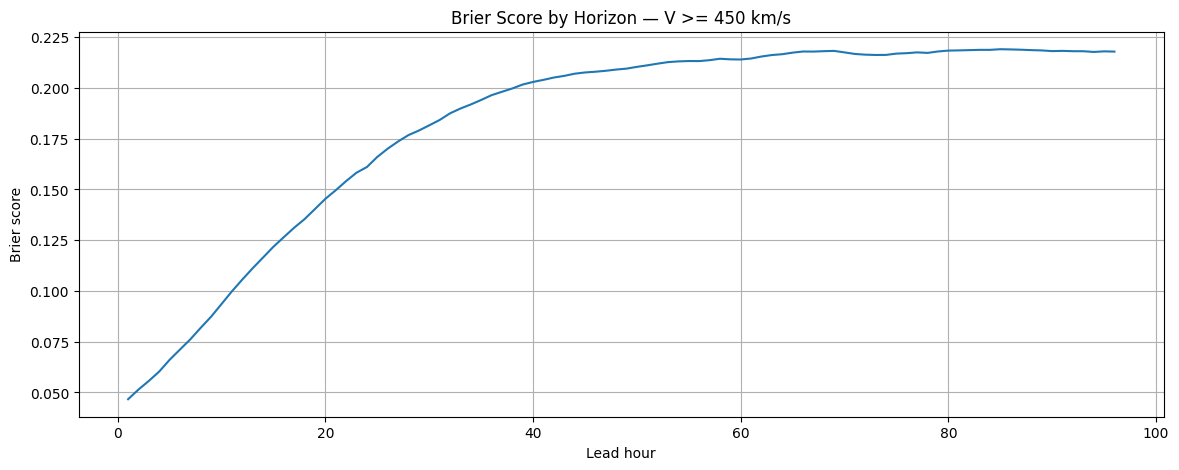

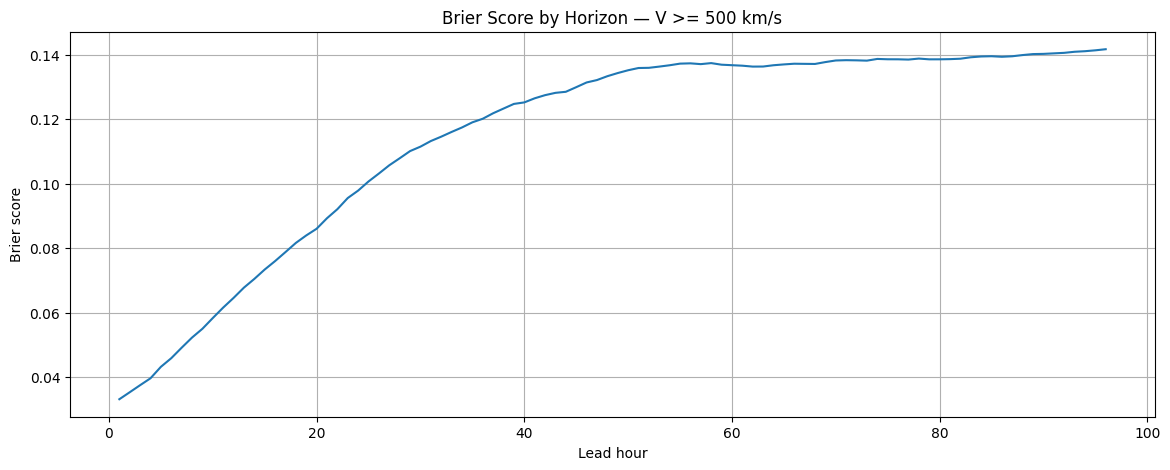

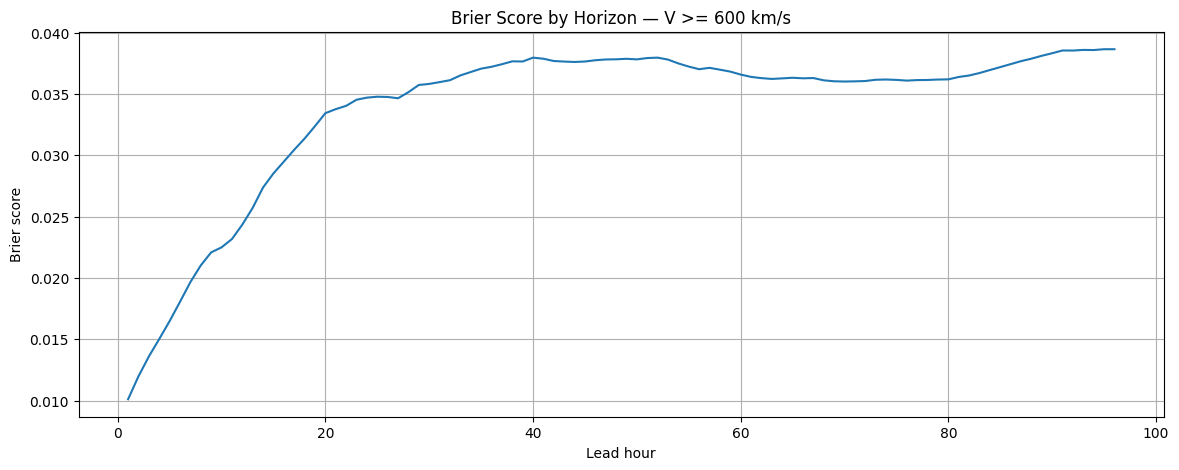

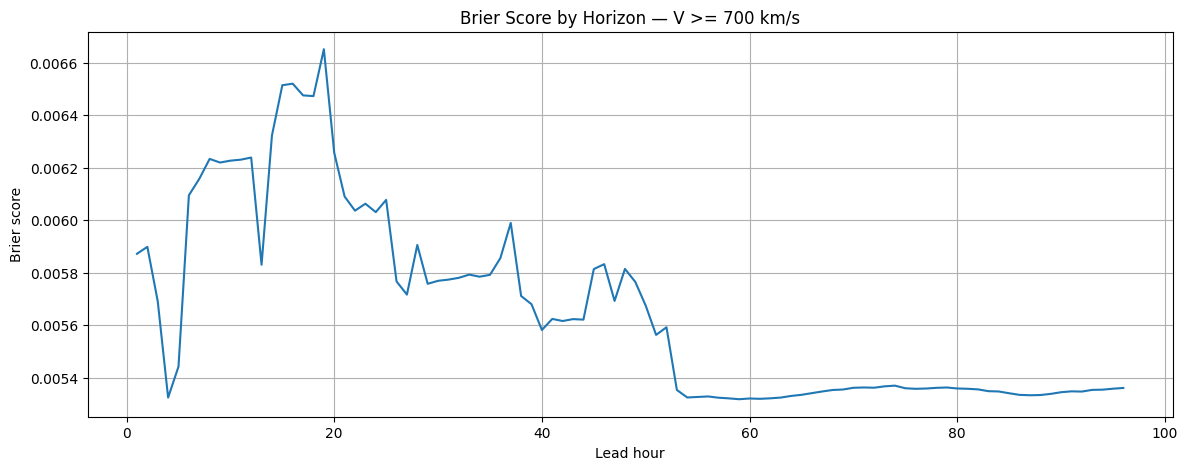

In [26]:
for threshold in THRESHOLDS:
    g = event_by_lead[event_by_lead["threshold"] == threshold]

    plt.figure(figsize=(14, 5))
    plt.plot(g["lead_hours"], g["brier"])
    plt.xlabel("Lead hour")
    plt.ylabel("Brier score")
    plt.title(f"Brier Score by Horizon — V >= {threshold} km/s")
    plt.grid(True)
    plt.show()

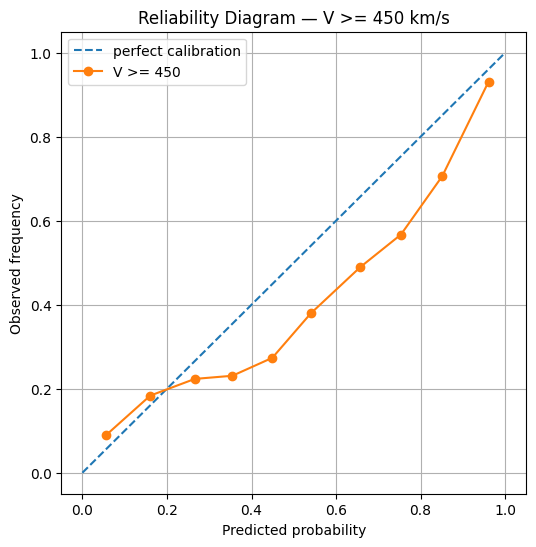

,bin,mean_probability,observed_frequency,count
0,"(-0.001, 0.1]",0.055630,0.089203,46848
1,"(0.1, 0.2]",0.160423,0.183576,39139
2,"(0.2, 0.3]",0.265831,0.223364,103374
3,"(0.3, 0.4]",0.354829,0.230860,139933
4,"(0.4, 0.5]",0.449255,0.273589,51603
5,"(0.5, 0.6]",0.540215,0.379356,32882
6,"(0.6, 0.7]",0.657057,0.489310,9121
7,"(0.7, 0.8]",0.753520,0.567098,9963
8,"(0.8, 0.9]",0.851274,0.706176,6800
9,"(0.9, 1.0]",0.960949,0.931405,14316


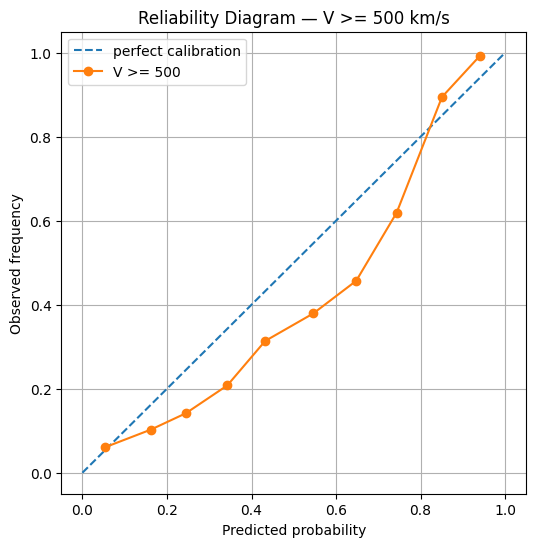

,bin,mean_probability,observed_frequency,count
0,"(-0.001, 0.1]",0.054605,0.061038,93007
1,"(0.1, 0.2]",0.162030,0.102681,160097
2,"(0.2, 0.3]",0.244679,0.141568,126102
3,"(0.3, 0.4]",0.342822,0.207929,40966
4,"(0.4, 0.5]",0.432330,0.313673,9003
5,"(0.5, 0.6]",0.546162,0.379237,5606
6,"(0.6, 0.7]",0.647734,0.456962,6018
7,"(0.7, 0.8]",0.743326,0.619100,7309
8,"(0.8, 0.9]",0.850641,0.894620,3160
9,"(0.9, 1.0]",0.939623,0.991885,2711


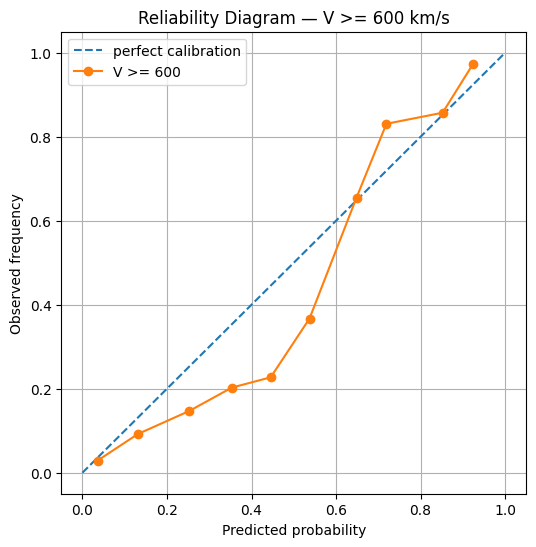

,bin,mean_probability,observed_frequency,count
0,"(-0.001, 0.1]",0.036044,0.028991,421757
1,"(0.1, 0.2]",0.131345,0.092233,24232
2,"(0.2, 0.3]",0.252903,0.147091,3644
3,"(0.3, 0.4]",0.353227,0.202570,1323
4,"(0.4, 0.5]",0.445371,0.227143,700
5,"(0.5, 0.6]",0.537207,0.367036,1444
6,"(0.6, 0.7]",0.648464,0.655093,432
7,"(0.7, 0.8]",0.719146,0.830769,130
8,"(0.8, 0.9]",0.852081,0.857143,245
9,"(0.9, 1.0]",0.923471,0.972222,72


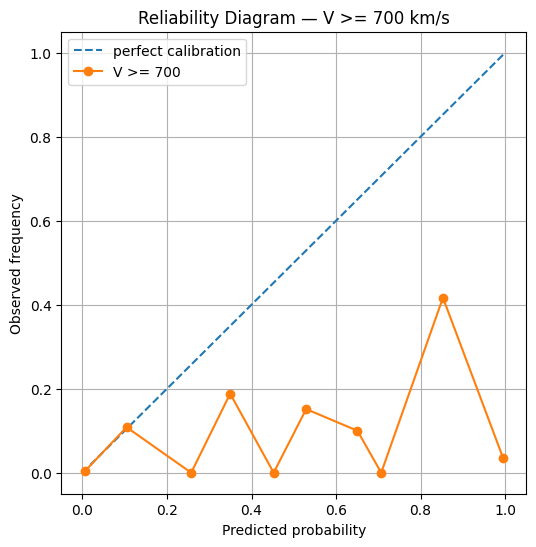

,bin,mean_probability,observed_frequency,count
0,"(-0.001, 0.1]",0.007200,0.005114,453304
1,"(0.1, 0.2]",0.104478,0.108359,323
2,"(0.2, 0.3]",0.257335,0.000000,1
3,"(0.3, 0.4]",0.349553,0.188235,85
4,"(0.4, 0.5]",0.452423,0.000000,5
5,"(0.5, 0.6]",0.529349,0.151515,33
6,"(0.6, 0.7]",0.650519,0.100000,10
7,"(0.7, 0.8]",0.706828,0.000000,2
8,"(0.8, 0.9]",0.852872,0.416667,12
9,"(0.9, 1.0]",0.995489,0.034314,204


In [27]:
def reliability_table(df, threshold, bins=10):
    target_col = f"target_v_ge_{threshold}"
    prob_col = f"prob_v_ge_{threshold}"

    tmp = df[[target_col, prob_col]].copy()
    tmp["bin"] = pd.cut(
        tmp[prob_col],
        bins=np.linspace(0, 1, bins + 1),
        include_lowest=True,
    )

    out = (
        tmp.groupby("bin", observed=True)
        .agg(
            mean_probability=(prob_col, "mean"),
            observed_frequency=(target_col, "mean"),
            count=(target_col, "size"),
        )
        .reset_index()
    )

    return out


for threshold in THRESHOLDS:
    rel = reliability_table(test_events, threshold, bins=10)

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")
    plt.plot(
        rel["mean_probability"],
        rel["observed_frequency"],
        marker="o",
        label=f"V >= {threshold}",
    )

    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.title(f"Reliability Diagram — V >= {threshold} km/s")
    plt.grid(True)
    plt.legend()
    plt.show()

    display(rel)

In [28]:
def plot_event_forecast(issue_time):
    issue_time = pd.Timestamp(issue_time, tz="UTC")

    g = test_events[test_events["issue_time"] == issue_time].sort_values("lead_hours")

    if g.empty:
        print(f"No rows for issue_time={issue_time}")
        return

    plt.figure(figsize=(14, 6))

    for threshold in THRESHOLDS:
        plt.plot(
            g["lead_hours"],
            g[f"prob_v_ge_{threshold}"],
            label=f"P(V >= {threshold})",
            linewidth=2,
        )

    plt.xlabel("Lead hour")
    plt.ylabel("Probability")
    plt.title(f"High-Speed Event Probabilities from {issue_time}")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(14, 6))
    plt.plot(g["lead_hours"], g["target_v"], label="observed V", linewidth=2)

    for threshold in THRESHOLDS:
        plt.axhline(threshold, linestyle="--", linewidth=1, label=f"{threshold} km/s")

    plt.xlabel("Lead hour")
    plt.ylabel("Solar wind speed, km/s")
    plt.title(f"Observed Speed Path from {issue_time}")
    plt.grid(True)
    plt.legend()
    plt.show()

In [29]:
interesting_issues = (
    test_events
    .groupby("issue_time")["target_v"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

interesting_issues

issue_time
2023-11-08 05:00:00+00:00    735.0
2023-11-08 04:00:00+00:00    735.0
2023-11-08 03:00:00+00:00    735.0
2023-11-08 02:00:00+00:00    735.0
2023-11-08 07:00:00+00:00    735.0
2023-11-08 06:00:00+00:00    735.0
2023-11-05 22:00:00+00:00    735.0
2023-11-05 21:00:00+00:00    735.0
2023-11-05 20:00:00+00:00    735.0
2023-11-06 11:00:00+00:00    735.0
Name: target_v, dtype: float64

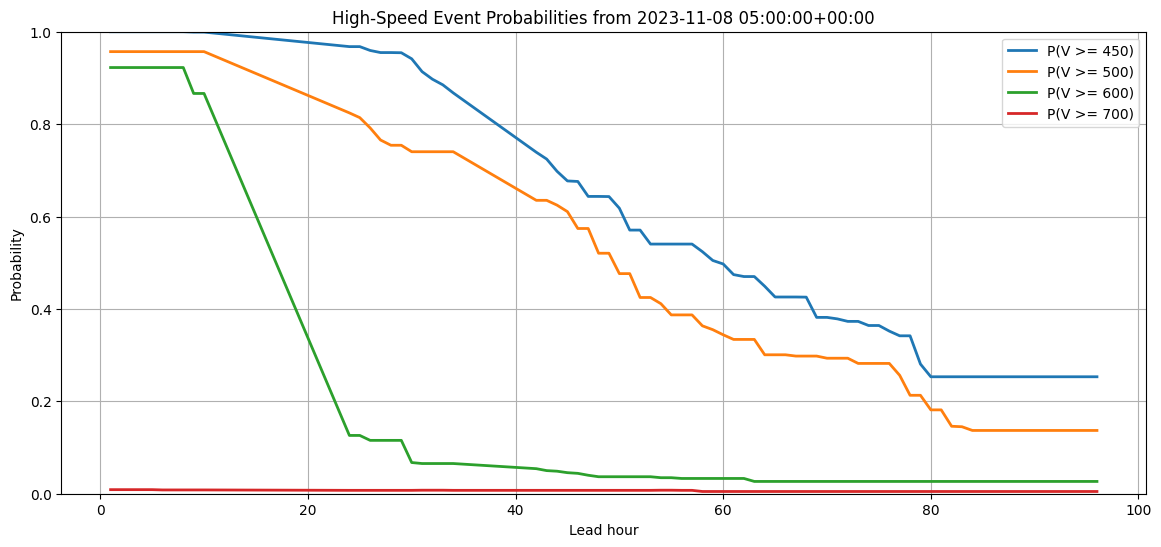

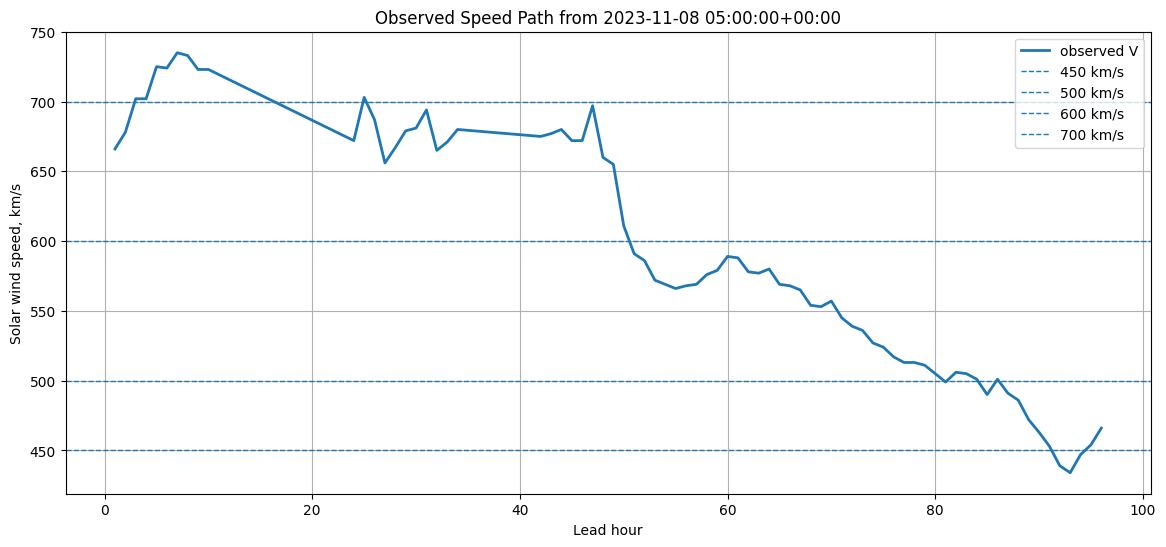

In [31]:
plot_event_forecast("2023-11-08 05:00:00+00:00")

In [32]:
test_events.to_csv("../../reports/speed_event_test_predictions.csv", index=False)
event_metrics.to_csv("../../reports/speed_event_test_metrics.csv", index=False)
event_by_lead.to_csv("../../reports/speed_event_test_metrics_by_lead.csv", index=False)

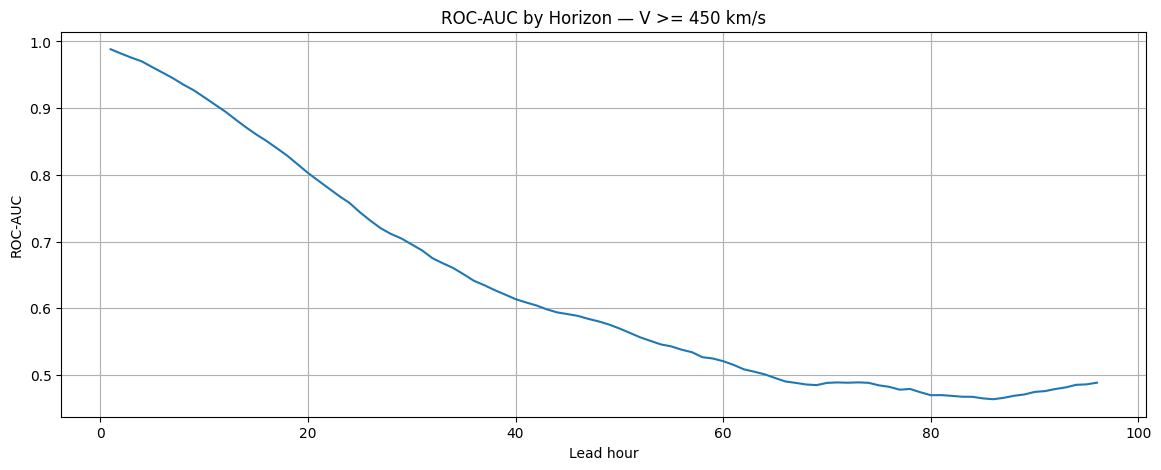

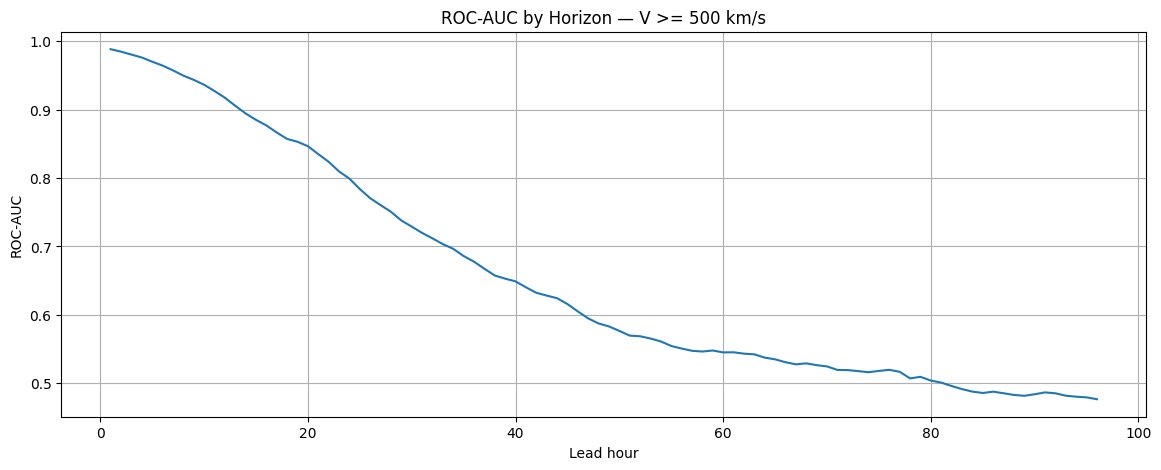

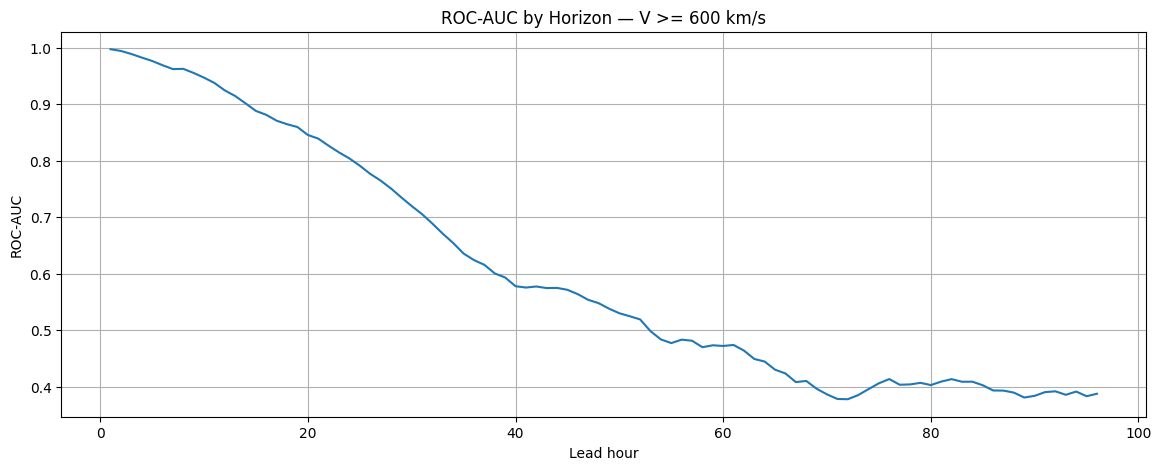

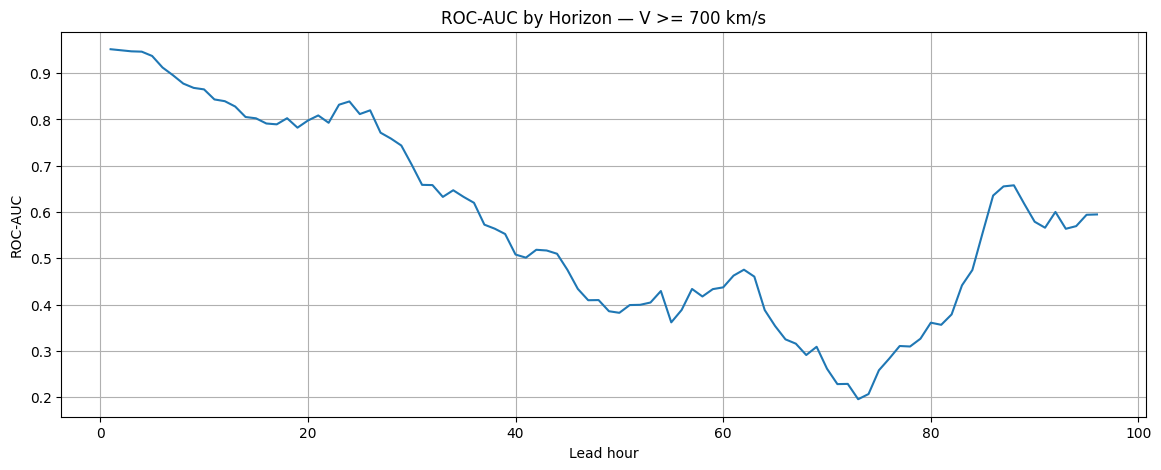

In [33]:
for threshold in THRESHOLDS:
    g = event_by_lead[event_by_lead["threshold"] == threshold]

    plt.figure(figsize=(14, 5))
    plt.plot(g["lead_hours"], g["roc_auc"])
    plt.xlabel("Lead hour")
    plt.ylabel("ROC-AUC")
    plt.title(f"ROC-AUC by Horizon — V >= {threshold} km/s")
    plt.grid(True)
    plt.show()